## 1. Imports

In [19]:
import requests
import time
import json
import pandas               as pd
import plotly.express       as px
import plotly.graph_objects as go
import matplotlib.pyplot    as plt
import seaborn              as sns

from pathlib import Path
from datetime import datetime
from wordcloud import WordCloud


## 2. Funções

In [2]:
# funçoes para coletar os dados da API

LIMITE_TOTAL_EDITAIS = 3000

def coletarEditaisModalidade(codigo_modalidade, data_inicial, data_final, limite_restante):
    #Coleta editais de uma modalidade específica, respeitando um limite máximo de registros a coletar

    editais = []
    pagina = 1
    
    while True:
        if len(editais) >= limite_restante:
            print(f"Limite de coleta atingido para esta modalidade. Parando.")
            break
        
        params = {
            "dataInicial": data_inicial,
            "dataFinal": data_final,
            "codigoModalidadeContratacao": codigo_modalidade,
            "pagina": pagina,
            "tamanhoPagina": TAMANHO_PAGINA
        }
        
        response = requests.get(BASE_URL, params=params)
        
        if response.status_code == 429:
            print(f"Rate limit atingido na página {pagina}. Esperando 5s ...")
            time.sleep(5)
            continue
        
        if response.status_code != 200:
            print(f"Erro na modalidade {codigo_modalidade}, na página {pagina}: status {response.status_code}")
            break
        
        dados = response.json()
        registros = dados.get("data", [])
        
        if not registros:
            break
        
        editais.extend(registros)
        
        total_paginas = dados.get("totalPaginas", 1)
        print(f"Modalidade {codigo_modalidade} - página {pagina}/{total_paginas} - {len(registros)} registros (acumulado: {len(editais)})")
        
        if pagina >= total_paginas:
            break
        
        pagina += 1
        time.sleep(1.5)
    
    return editais


def coletarTodasModalidades(modalidades, data_inicial, data_final, limite_total):
    #Roda a coleta para cada modalidade, parando quando o limite GLOBAL é atingido. nao vi ter um numero certo para cada modalidade, para trazer o retrato da realidade

    todos_editais = []
    
    for codigo, nome in modalidades.items():
        limite_restante = limite_total - len(todos_editais)
        
        if limite_restante <= 0:
            print(f"\nLimite total de {limite_total} já atingido. Pulando modalidade {nome}.")
            break
        
        print(f"\n- Coletando: {nome} (código {codigo}) - restam {limite_restante} para o limite total -")
        editais_modalidade = coletarEditaisModalidade(codigo, data_inicial, data_final, limite_restante)
        
        for edital in editais_modalidade:
            edital["modalidade_nome"] = nome
        
        todos_editais.extend(editais_modalidade)
        print(f"Total coletado para {nome}: {len(editais_modalidade)} | Total geral acumulado: {len(todos_editais)}")
    
    return todos_editais

## 3. Coleta de dados (ELT) - API do PNCP (Potal Nascional de Contas Publicas)

In [3]:
# configuraçoes essenciais para puxar os dados certos da API

BASE_URL = "https://pncp.gov.br/api/consulta/v1/contratacoes/publicacao"
DADOS_RAW_PATH = Path("../dados/raw")
DADOS_RAW_PATH.mkdir(parents=True, exist_ok=True)

DATA_INICIAL = "20260601"
DATA_FINAL = "20260603"

MODALIDADES = {
    4: "Concorrência - Eletrônica",
    5: "Concorrência - Presencial",
    6: "Pregão - Eletrônico",
    7: "Pregão - Presencial",
    8: "Dispensa de Licitação",
    9: "Inexigibilidade"
}

TAMANHO_PAGINA = 50

In [4]:
# coletando os dados 

todos_editais = coletarTodasModalidades( modalidades=MODALIDADES,
                                        data_inicial= DATA_INICIAL,
                                        data_final= DATA_FINAL,
                                        limite_total= LIMITE_TOTAL_EDITAIS )

print(f"Total de editais coletados: {len(todos_editais)}")


- Coletando: Concorrência - Eletrônica (código 4) - restam 3000 para o limite total -
Modalidade 4 - página 1/22 - 50 registros (acumulado: 50)
Modalidade 4 - página 2/22 - 50 registros (acumulado: 100)
Modalidade 4 - página 3/22 - 50 registros (acumulado: 150)
Modalidade 4 - página 4/22 - 50 registros (acumulado: 200)
Modalidade 4 - página 5/22 - 50 registros (acumulado: 250)
Modalidade 4 - página 6/22 - 50 registros (acumulado: 300)
Modalidade 4 - página 7/22 - 50 registros (acumulado: 350)
Modalidade 4 - página 8/22 - 50 registros (acumulado: 400)
Modalidade 4 - página 9/22 - 50 registros (acumulado: 450)
Rate limit atingido na página 10. Esperando 5s ...
Rate limit atingido na página 10. Esperando 5s ...
Rate limit atingido na página 10. Esperando 5s ...
Rate limit atingido na página 10. Esperando 5s ...
Modalidade 4 - página 10/22 - 50 registros (acumulado: 500)
Modalidade 4 - página 11/22 - 50 registros (acumulado: 550)
Modalidade 4 - página 12/22 - 50 registros (acumulado: 600)

### 3.1 Salvando o Dataset Bruto

In [5]:
caminho_arquivo = DADOS_RAW_PATH / "editais.json"

with open(caminho_arquivo, "w", encoding="utf-8") as f:
    json.dump(todos_editais, f, ensure_ascii=False, indent=2)

print(f"salvos {len(todos_editais)} editais em {caminho_arquivo}")


salvos 3010 editais em ../dados/raw/editais.json


### 3.2 Transformando em DataFrame

In [6]:
df = pd.DataFrame(todos_editais)

# aproeitando o rotulo que ja veem para categorizar os dados
df['categoria'] = df['modalidade_nome']

print(f"total de registros {len(df)}")
print( df['categoria'].value_counts())

total de registros 3010
categoria
Pregão - Eletrônico          1900
Concorrência - Eletrônica    1060
Concorrência - Presencial      50
Name: count, dtype: int64


## 4. Análise Exploratória dos Dados

### 4.1 Distribuição de categorias

Analisar o volume de editais por modalidade de contratação. Avaliar o desbalanceamento das categorias.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_43033/536286602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_categorias, x="categoria", y="quantidade", palette="Blues_d")


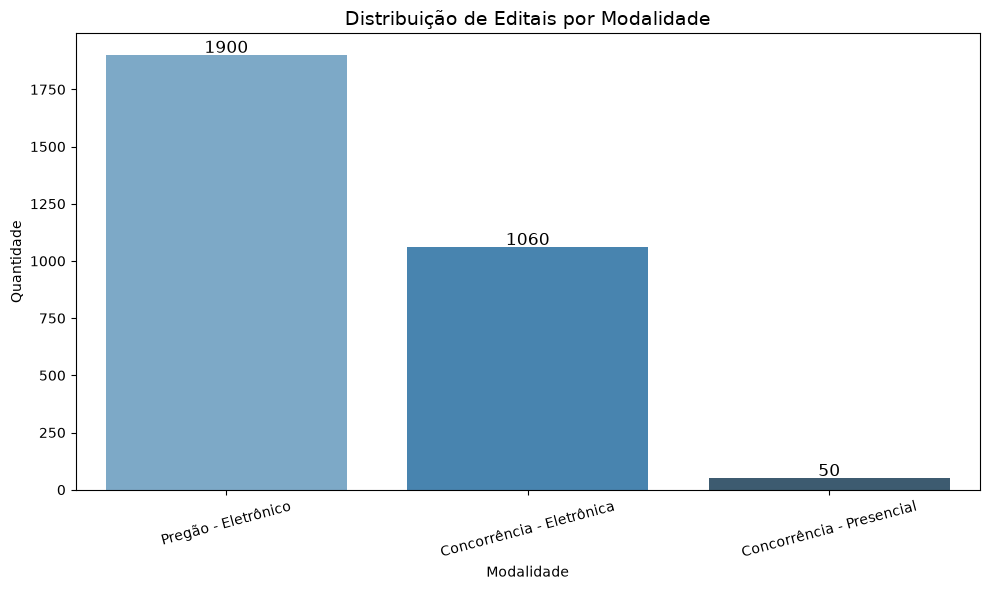

In [20]:
contagem_categorias = df["categoria"].value_counts().reset_index()
contagem_categorias.columns = ["categoria", "quantidade"]

plt.figure(figsize=(10, 6))
sns.barplot(data=contagem_categorias, x="categoria", y="quantidade", palette="Blues_d")

for i, row in contagem_categorias.iterrows():
    plt.text(i, row["quantidade"] + 10, str(row["quantidade"]), ha="center", fontsize=12)

plt.title("Distribuição de Editais por Modalidade", fontsize=14)
plt.xlabel("Modalidade")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.tight_layout()
#plt.savefig("../dados/processed/plot_distribuicao_categorias.png", dpi=150)
plt.show()

### 4.2 Tamanho dos Textos

Analisar o comprimento do campo "objetoCompra"que será o texto principal a ser utilizado.

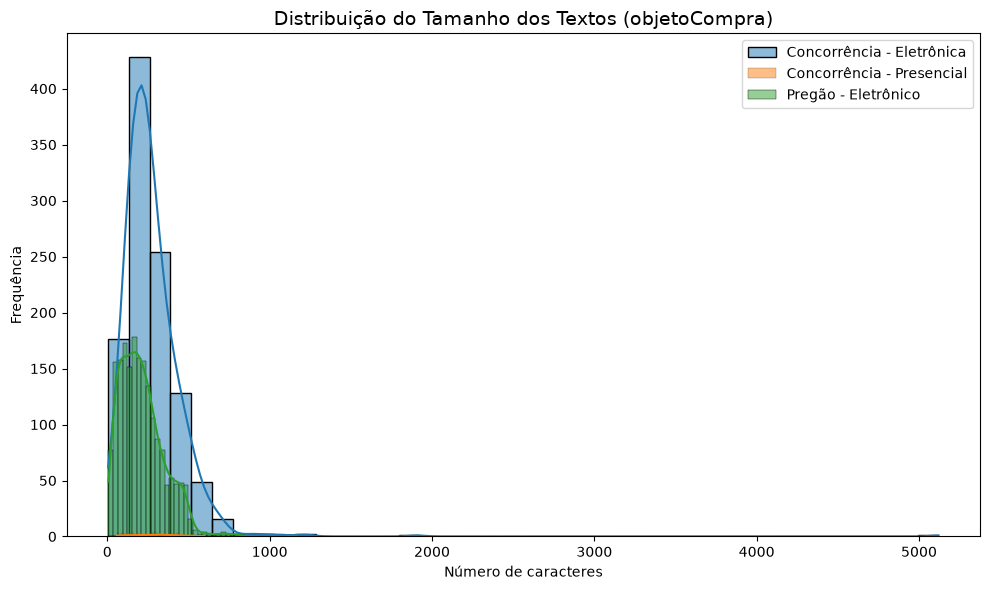

                            count    mean     std   min     25%    50%    75%  \
categoria                                                                       
Concorrência - Eletrônica  1060.0  274.28  219.58   5.0  163.00  238.0  343.0   
Concorrência - Presencial    50.0  288.74  147.56  59.0  164.25  294.0  391.0   
Pregão - Eletrônico        1900.0  214.49  139.05   7.0  109.00  192.0  288.0   

                              max  
categoria                          
Concorrência - Eletrônica  5120.0  
Concorrência - Presencial   596.0  
Pregão - Eletrônico        1164.0  


In [21]:
df["tamanho_objeto"] = df["objetoCompra"].fillna("").apply(len)

plt.figure(figsize=(10, 6))
for categoria, grupo in df.groupby("categoria"):
    sns.histplot(grupo["tamanho_objeto"], label=categoria, kde=True, alpha=0.5, bins=40)

plt.title("Distribuição do Tamanho dos Textos (objetoCompra)", fontsize=14)
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.savefig("../dados/processed/plot_tamanho_textos.png", dpi=150)
plt.show()

print(df.groupby("categoria")["tamanho_objeto"].describe().round(2))

### 4.3 Nuvem de Palavras

Visualizar os termos mais frequentes nos objetos dos editais.

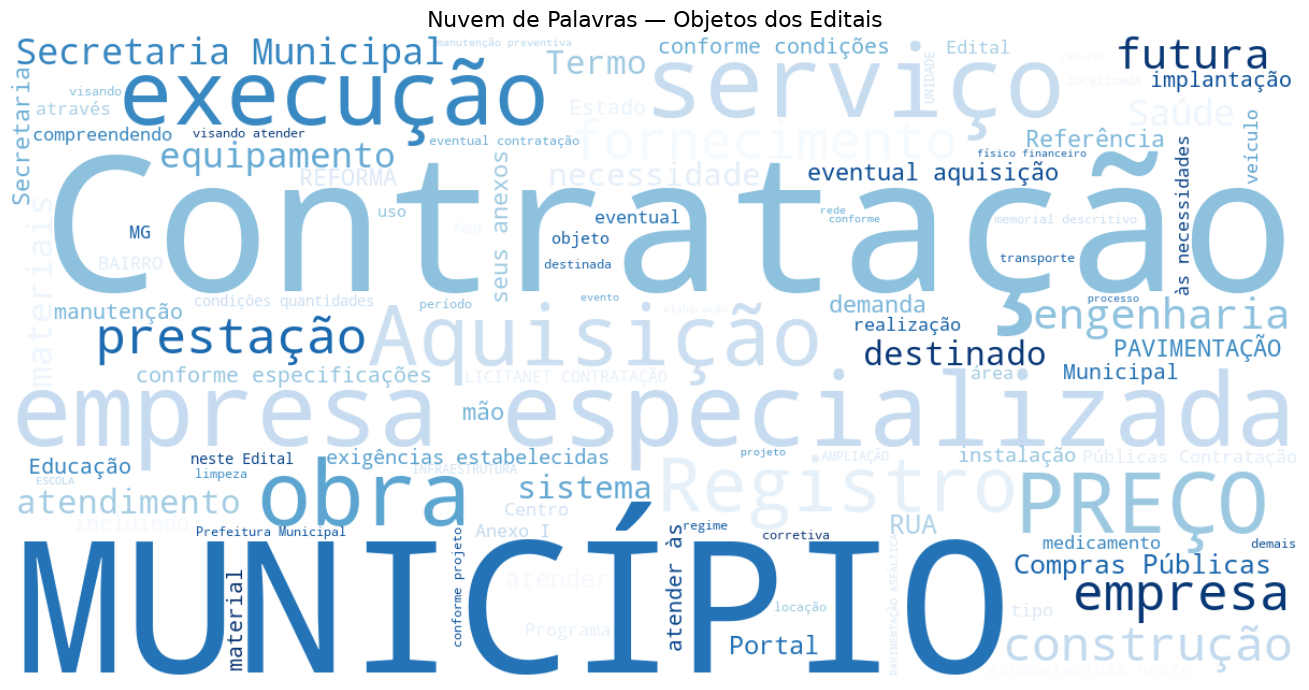

In [13]:
texto_completo = " ".join(df["objetoCompra"].fillna("").tolist())

stopwords_pt = {
    "de", "da", "do", "das", "dos", "e", "a", "o", "as", "os",
    "em", "para", "com", "por", "um", "uma", "no", "na", "nos",
    "nas", "ao", "aos", "ou", "que", "se", "não", "à", "pelo",
    "pela", "ser", "este", "esta", "esse", "essa", "the", "of"
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords_pt,
    max_words=100,
    colormap="Blues"
).generate(texto_completo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras — Objetos dos Editais", fontsize=16)
plt.tight_layout()
plt.savefig("../dados/processed/wordcloud_editais.png", dpi=150)
plt.show()

### 4.4 Valor estimado por categoria

Analisar a distribuição de valores por modalidade, permitindo identificar qual modalidade concentra maior valor financeiro.

In [23]:
df_valor = df[df["valorTotalEstimado"].notna()].copy()

fig4 = px.box(
    df_valor,
    x="categoria",
    y="valorTotalEstimado",
    color="categoria",
    title="Distribuição do Valor Estimado por Modalidade",
    log_y=True
)

fig4.update_layout(
    xaxis_title="Modalidade",
    yaxis_title="Valor Estimado (R$) — escala log",
    showlegend=False
)
fig4.show()

resumo = df_valor.groupby("categoria")["valorTotalEstimado"].describe().round(2)
print(resumo)

                            count         mean           std   min        25%  \
categoria                                                                       
Concorrência - Eletrônica  1060.0   4048218.40  1.381271e+07  0.00  345211.26   
Concorrência - Presencial    50.0  37371642.28  2.462210e+08  0.01  356280.03   
Pregão - Eletrônico        1900.0   1682409.46  9.378938e+06  0.00   29455.58   

                                 50%         75%           max  
categoria                                                       
Concorrência - Eletrônica  937290.51  2843762.30  1.975608e+08  
Concorrência - Presencial  970976.04  3532988.14  1.743399e+09  
Pregão - Eletrônico        195664.41   819838.75  2.113937e+08  


### 4.5 Visualização por Estado

Identificar os estados com maior volume de editais publicados.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_43033/900350814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_uf.head(10), x="uf", y="quantidade", palette="Blues_d")


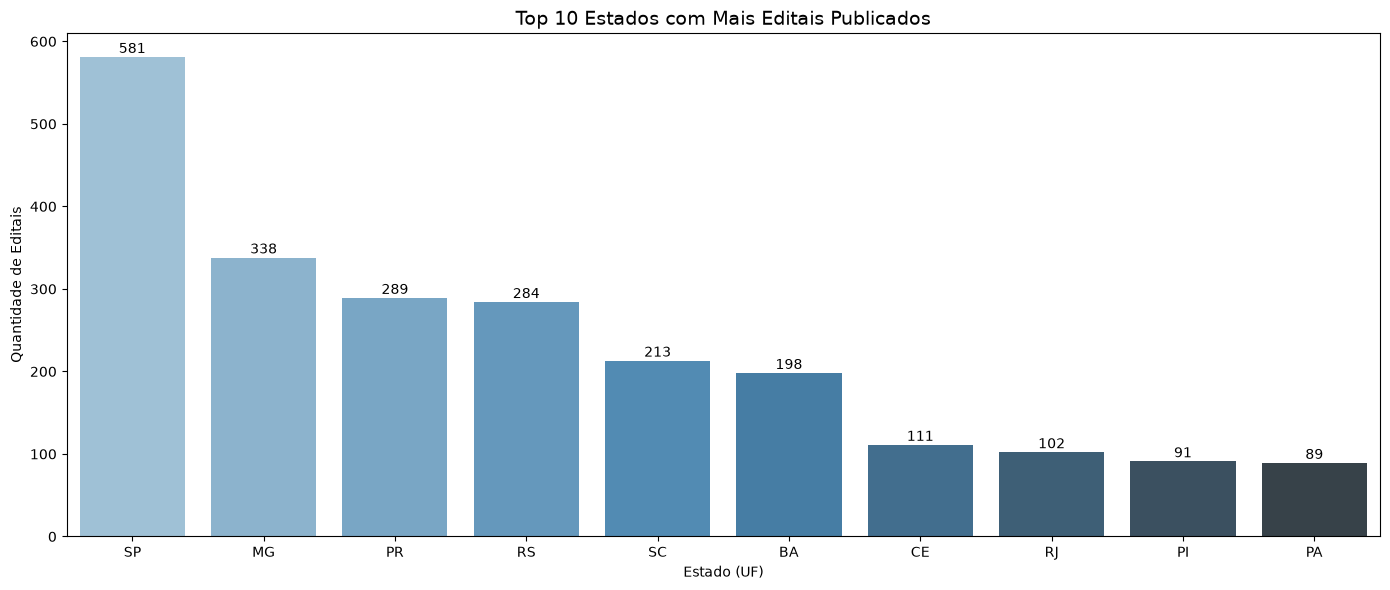

In [28]:
df["uf"] = df["unidadeOrgao"].apply(
    lambda x: x.get("ufSigla") if isinstance(x, dict) else None)

contagem_uf = df["uf"].value_counts().reset_index()
contagem_uf.columns = ["uf", "quantidade"]

plt.figure(figsize=(14, 6))
sns.barplot(data=contagem_uf.head(10), x="uf", y="quantidade", palette="Blues_d")

for i, row in contagem_uf.head(10).iterrows():
    plt.text(i, row["quantidade"] + 5, str(row["quantidade"]), ha="center", fontsize=10)

plt.title("Top 10 Estados com Mais Editais Publicados", fontsize=14)
plt.xlabel("Estado (UF)")
plt.ylabel("Quantidade de Editais")
plt.tight_layout()
#plt.savefig("../dados/processed/plot_distribuicao_uf.png", dpi=150)
plt.show()

### 4.6 Órgãos Compradores

Identificar quais órgãos são os maiores compradores públicos.

In [16]:
df["orgao"] = df["unidadeOrgao"].apply(
    lambda x: x.get("nomeUnidade") if isinstance(x, dict) else None
)

top_orgaos = df["orgao"].value_counts().head(15).reset_index()
top_orgaos.columns = ["orgao", "quantidade"]

fig6 = px.bar(
    top_orgaos,
    x="quantidade",
    y="orgao",
    orientation="h",
    title="Top 15 Órgãos com Mais Editais Publicados",
    text="quantidade",
    color="quantidade",
    color_continuous_scale="Teal"
)

fig6.update_traces(textposition="outside")
fig6.update_layout(
    yaxis=dict(autorange="reversed"),
    xaxis_title="Quantidade de Editais",
    yaxis_title="Órgão"
)
fig6.show()

### 4.7 Evolução

Analisar o volume de editais publicados por dia, separando por modalidade.

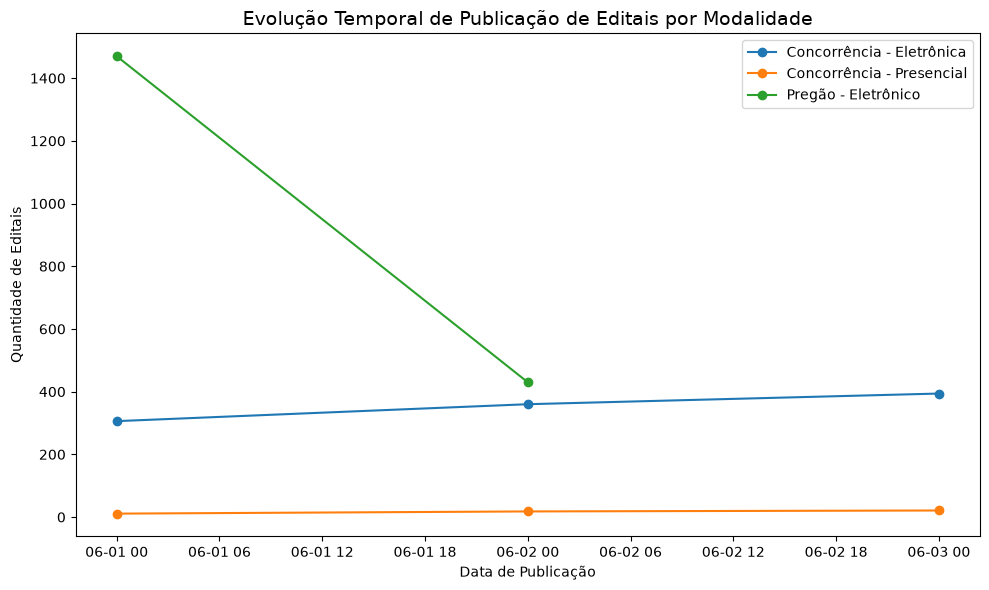

In [29]:
df["data_publicacao"] = pd.to_datetime(df["dataPublicacaoPncp"]).dt.date

evolucao = df.groupby(["data_publicacao", "categoria"]).size().reset_index()
evolucao.columns = ["data", "categoria", "quantidade"]

plt.figure(figsize=(10, 6))
for categoria, grupo in evolucao.groupby("categoria"):
    plt.plot(grupo["data"], grupo["quantidade"], marker="o", label=categoria)

plt.title("Evolução Temporal de Publicação de Editais por Modalidade", fontsize=14)
plt.xlabel("Data de Publicação")
plt.ylabel("Quantidade de Editais")
plt.legend()
plt.tight_layout()
plt.savefig("../dados/processed/plot_evolucao_temporal.png", dpi=150)
plt.show()